# State Injection

State injection encodes a physical state into a surface code logical patch.
The intended state is injected at a corner (or middle) qubit, then stabilized by SE rounds.
Post-selection discards shots where the specified detectors show errors.

Supported injection states: Z, X, Y.  
Post-selection modes: `full_postselection` (all-ancilla), `full_qec` (no post-select), `hybrid` (strip).

Readout:
- Z state → transversal MZ
- X state → transversal MX  
- Y state → **noiseless S†_L + transversal MX** (FT: S† maps |+i⟩→|+⟩, no error added)

Code: Unrotated Surface Code, d=3, p=1e-3.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.state_injection import StateInjectionExperiment
from lightstim.qec_code.surface_code.unrotated import (
    UnrotatedSurfaceCode,
    UnrotatedSurfaceCodeExtractionBlock,
    UnrotatedSurfaceCodeLogicalOpSet,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 2
protocol = "corner"   # "corner" or "middle"
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

## 1. Unrotated Surface Code: Z, X, Y Injection (d=3, rounds=2)

In [3]:
circuits = {}
for state in ["Z", "X", "Y"]:
    with contextlib.redirect_stdout(io.StringIO()):
        exp = StateInjectionExperiment(
            code_patch_class=UnrotatedSurfaceCode,
            extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
            op_set_class=UnrotatedSurfaceCodeLogicalOpSet,
            distance=d, rounds=rounds, inject_state=state,
            protocol=protocol,
            post_select_mode="full_postselection",
            noise_params=noise_params,
        )
        circuits[state] = exp.build()
    c = circuits[state]
    print(f"Unrotated {state} ({protocol}): {c.num_qubits} qubits, {c.num_detectors} detectors, {c.num_observables} obs")

Unrotated Z (corner): 25 qubits, 22 detectors, 1 obs
Unrotated X (corner): 25 qubits, 22 detectors, 1 obs
Unrotated Y (corner): 25 qubits, 22 detectors, 1 obs


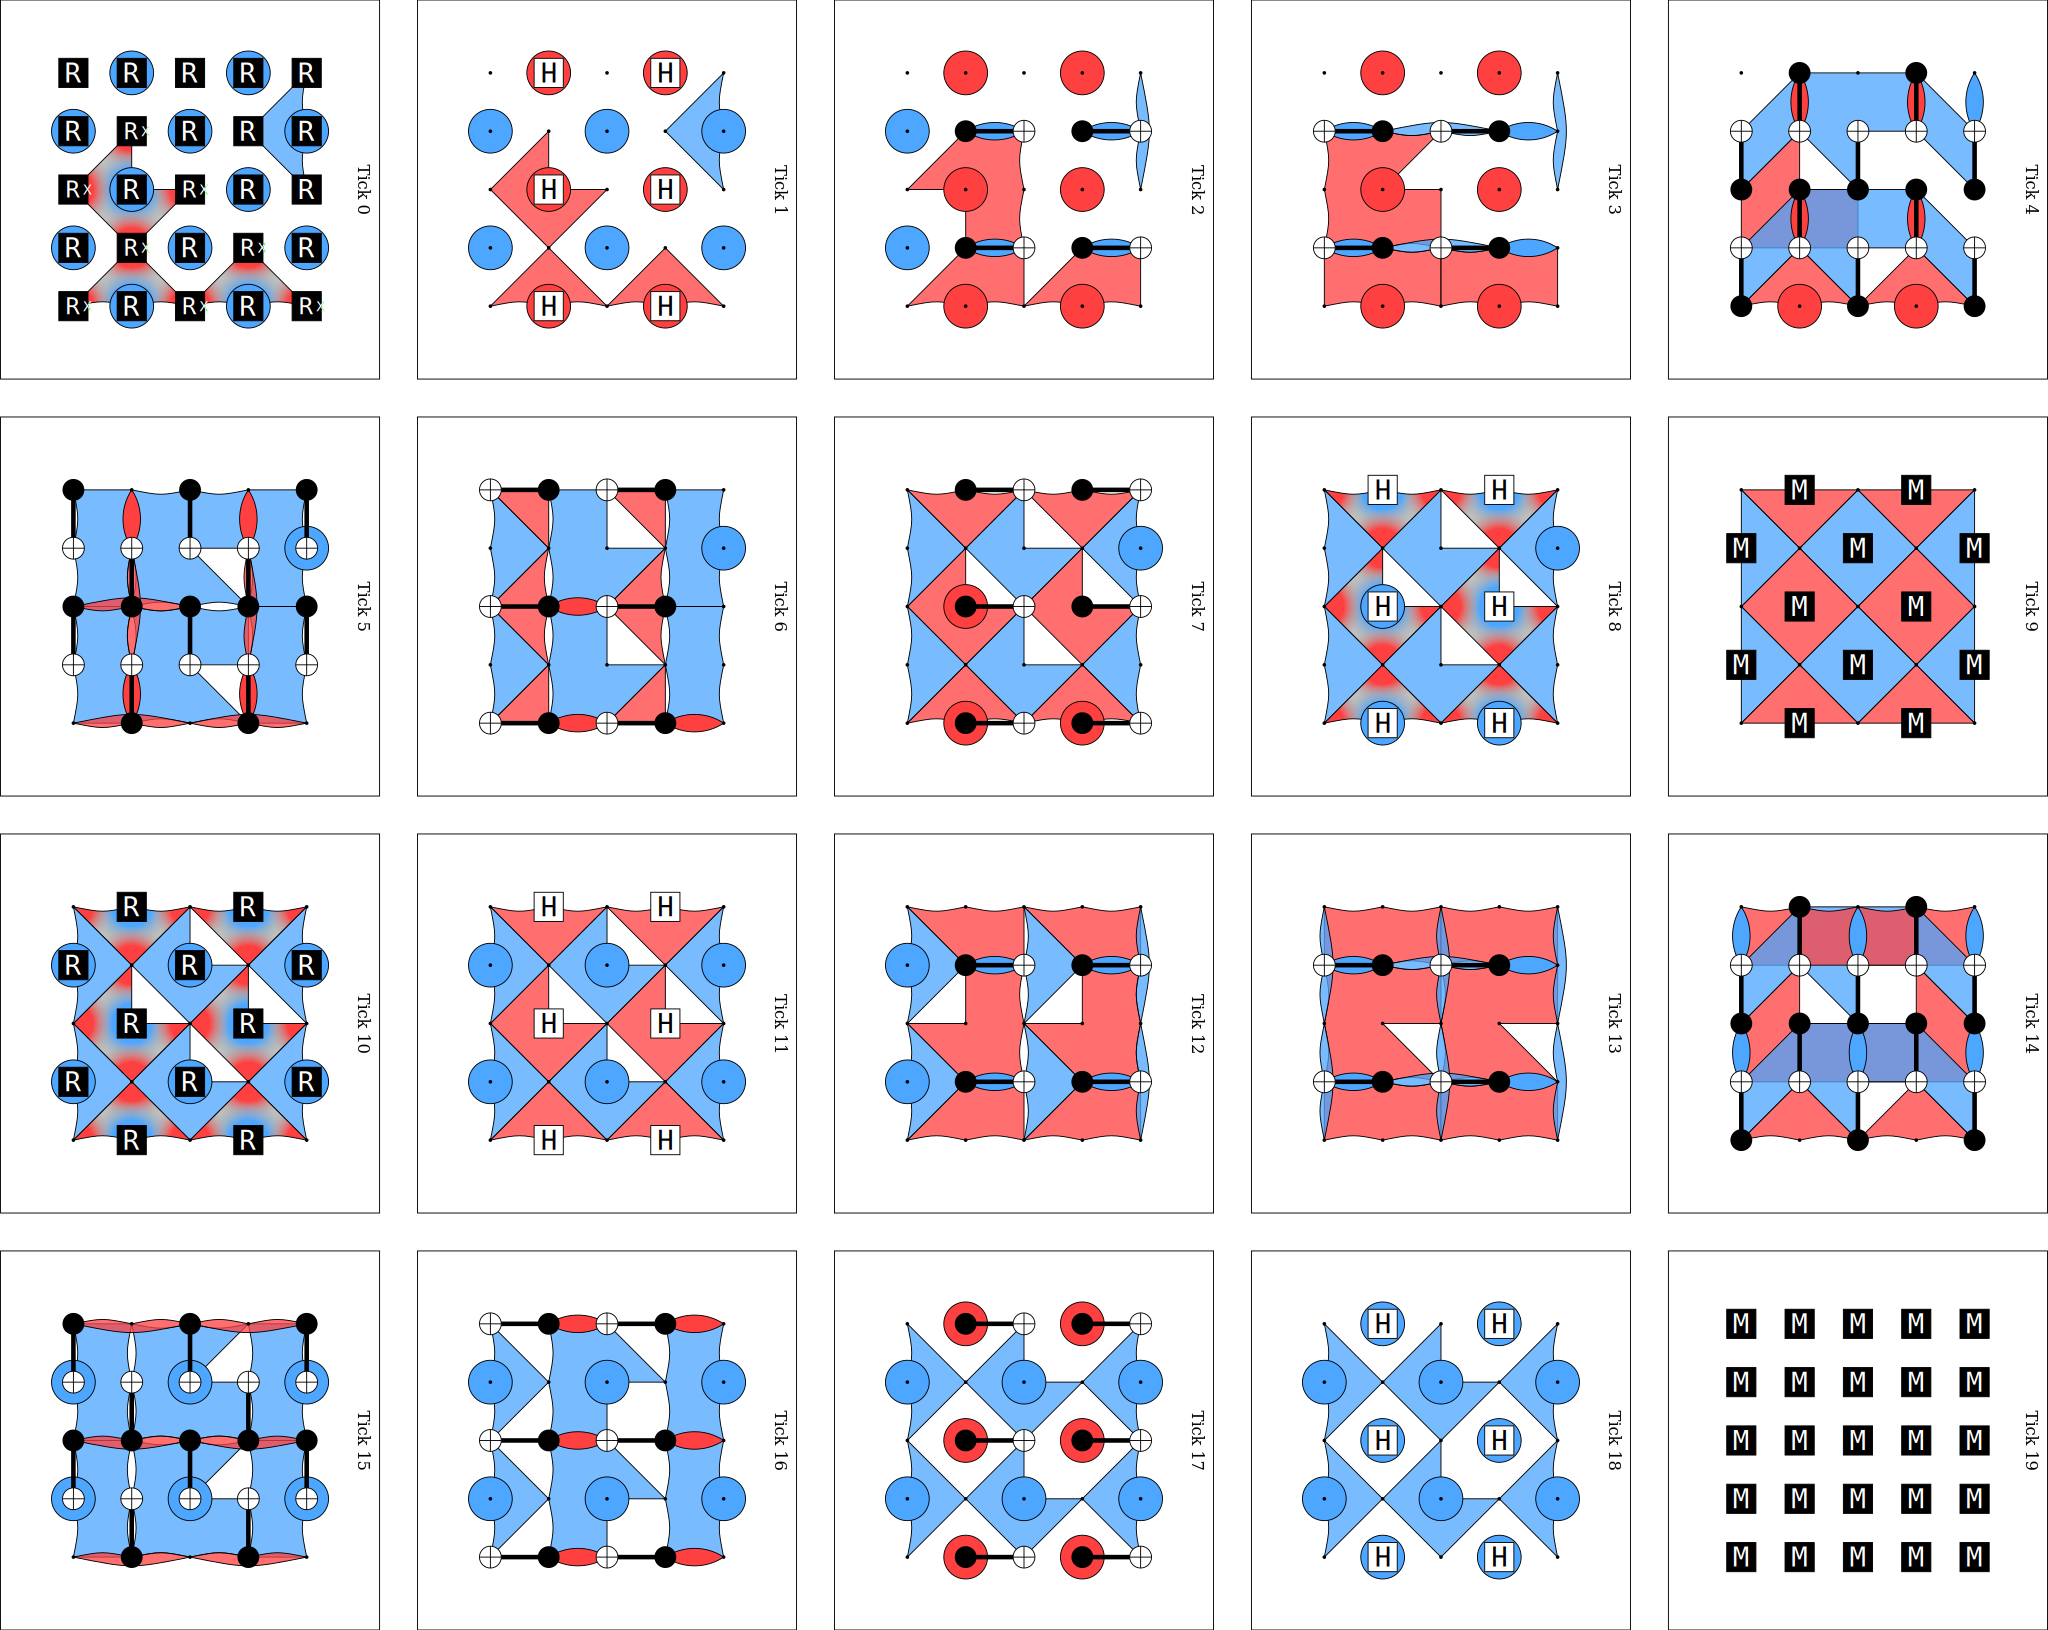

In [4]:
circuits["Z"].without_noise().diagram("detslice-with-ops-svg")

## 2. Noiseless Sanity Check

In [5]:
for state, circ in circuits.items():
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=500, separate_observables=True)
    print(f"Unrotated {state}: no logical errors={not obs.any()}")

Unrotated Z: no logical errors=True
Unrotated X: no logical errors=True
Unrotated Y: no logical errors=True


## 3. Simulation with PyMatching (100k shots, full post-selection)

In [6]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("pymatching", backend="cpu"),
    max_shots=100_000,
    max_errors=50,
    num_workers=4,
    print_progress=False,
)

for state, circ in circuits.items():
    stats = pipeline.run(circ)
    ps_rate = stats.post_selection_rate if stats.post_selection_rate is not None else float("nan")
    print(
        f"Unrotated {state}: "
        f"LER={stats.logical_error_rate:.2e}  "
        f"PS_rate={ps_rate:.2f}  "
        f"({stats.errors} errors / {stats.post_selected_shots:,} PS shots)"
    )

Unrotated Z: LER=3.71e-03  PS_rate=0.85  (63 errors / 17,000 PS shots)
Unrotated X: LER=2.35e-03  PS_rate=0.85  (80 errors / 34,059 PS shots)
Unrotated Y: LER=5.91e-03  PS_rate=0.85  (50 errors / 8,467 PS shots)


## 4. Post-Selection Mode Comparison (Z injection)

Compare `full_postselection`, `full_qec`, and `hybrid` for Z injection.

In [7]:
for mode in ["full_postselection", "full_qec", "hybrid"]:
    with contextlib.redirect_stdout(io.StringIO()):
        exp = StateInjectionExperiment(
            code_patch_class=UnrotatedSurfaceCode,
            extraction_block_class=UnrotatedSurfaceCodeExtractionBlock,
            op_set_class=UnrotatedSurfaceCodeLogicalOpSet,
            distance=d, rounds=rounds, inject_state="Z",
            protocol=protocol,
            post_select_mode=mode,
            noise_params=noise_params,
        )
        circ = exp.build()
    stats = pipeline.run(circ)
    ps_rate = stats.post_selection_rate if stats.post_selection_rate is not None else float("nan")
    print(
        f"Z {mode:20s}: "
        f"LER={stats.logical_error_rate:.2e}  "
        f"PS_rate={ps_rate:.2f}  "
        f"({stats.errors}/{stats.post_selected_shots:,})"
    )

Z full_postselection  : LER=3.81e-03  PS_rate=0.85  (65/17,062)
Z full_qec            : LER=1.05e-02  PS_rate=1.00  (105/10,000)
Z hybrid              : LER=3.69e-03  PS_rate=0.94  (69/18,704)
